# Uke 6 – Fri energi

## Diskusjonsoppgaver

### Oppgave 1: Hva er fri energi?

**a)** Hva er den fundamentale termodynamiske relasjonen for den indre energien U? Hvilke naturlige variable har U?

**b)** Hvordan definerer vi henholdsvis Helmholtz (A) og Gibbs (G) fri energi?

**c)** Bruk definisjonene i b og a til å komme fram til de fundamentale ligningene for Helmholtz og Gibbs fri energi.

**d)** Diskuter hva forskjellen er på indre energi og fri energi, og hvorfor dette kan være nyttig?


**e)** Hvorfor gir Gibbs maksimalt mulig *ikke-ekspansjonsarbeid* mens Helmholtz gir maksimalt mulig arbeid totalt?


### Oppgave 2: Illustrasjon av Helmholtz fri energi, dimerer eller monomerer

Dette eksempelet viser hvordan vi kan bruke *minimering av fri energi* til å forutsi likevekt. For å gjøre dette skal vi se på en enkel mikroskopisk modell som kombinerer energi- og entropibidrag: et system med to partikler som enten er *assosiert* (en dimer) eller *dissosiert* (to frie monomerer). Vi kan tenke på dette som at to atomer kan danne en binding eller være dissosiert som to enkeltatomer. 

**Gitt:** Vi har $N=2$ identiske partikler i en testrør modellert som et endimensjonalt gitter med $V$ plasser i rekkefølge, systemet er i et termisk likevekt med et varmebad med temperatur $T$:

- **Dimer-tilstand:** Når de to partiklene sitter på naboplasser, kan de danne en binding med energi $\varepsilon>0$. I dette forenklede systemet med to partikler er dette eneste bidraget til den indre energien $U=-\varepsilon$

- **Monomer-tilstand:** Når de to partiklene ikke er ved siden av hverandre kan de ikke danne noe binding og dermed er den indre energien null, $U=0$. De plasseres på to forskjellige plasser i gitteret, uten å være naboer.

![Dimer- og monomer-tilstand på et endimensjonalt gitter](../losningsforslag/dimer_monomer.png)

Vi ønsker å finne under hvilke betingelser systemet danner en dimer, og når det forblir som 2 separate partikler.

**a)** Diskuter følgende:

1) For dimeren, hvorfor er det det et minustegn i $U=-\varepsilon$?

2) Hvilke termodynamiske størrelser holder vi konstant her, og hvilket uttrykk for den frie energien må vi da bruke?

3) Hva forventer vi skjer med den frie energien ved likevekt?


**b)** Regn ut på hvor mange forskjellige plasser *dimeren* kan være i, anta at antall gitterplasser $V$ er veldig stort og $V\gg 1$.  


**c)** Bruk dette til å finne et uttrykk for entropien og Helmholtz fri energi for **dimer-tilstanden**.


**d)** Vis først at totalt antall mulige måter å plassere 2 partikler i $V$ bokser er gitt ved: 

$$ W_{tot}=\frac{V\cdot{(V-1)}}{2}$$

Bruk så dette og svaret i oppgave *b* til å finne antall måter vi kan plassere 2 partikler i $V$ bokser uten at de er ved siden av hverandre, altså i monomertilstand.  


**e)** Finn et uttrykk for entropien og Helmholtz fri energi for **monomer-tilstanden**. 

**f)** Finn krysstemperaturen $T_0$ der de to tilstandene er like stabile (lik fri energi). Hvorfor er dimeren den mest stabile tilstanden ved $T<T_0$, og monomeren ved $T>T_0$? Hvordan avhenger $T_0$ av $\varepsilon$ og $V$?

**f)** Under finner dere pythonkodeutsnitt som vil plotte den frie energien for monomeren og den frie energien for dimeren, Men dere må først fylle ut utrykkene for hver av de to. "A_dimer" og "A_momonmer". Figuren over viser $A(T)$ for $V=100$ og $\varepsilon=1.6605\cdot10^{-20}\ \mathrm{J}$. Forklar med utgangspunkt i figuren hvorfor dimeren dominerer ved lav temperatur og monomerene ved høy temperatur, og hva stigningstallene representerer fysisk.

Krysstemperatur T0 = 307.4 K


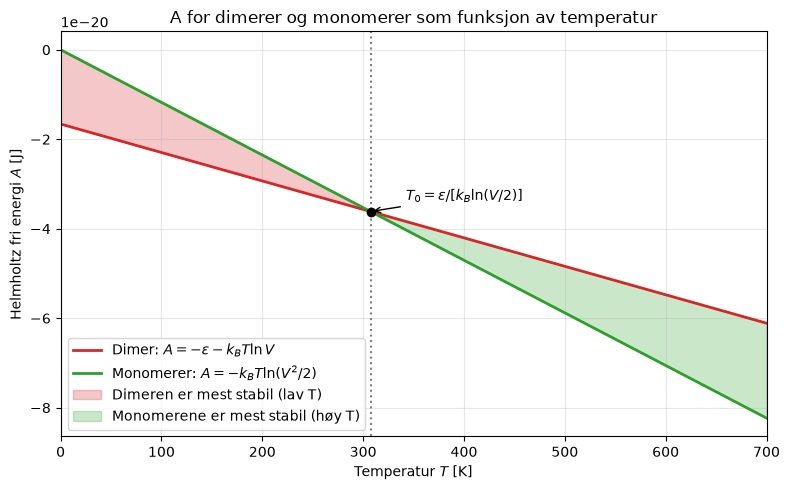

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Modellverdier: energi per partikkel.
# eps i joule (10 kJ/mol / N_A), k_B i J/K -> alt i reelle enheter.
V = 100.0      # antall gitterplasser
eps = 1.6605e-20   # bindingsenergi per partikkel [J] = 10 kJ/mol
k_B = 1.380649e-23  # Boltzmanns konstant [J K^-1]

T = np.linspace(0, 700, 400)
A_dimer = (-eps - k_B * T * np.log(V))      # i joule
A_monomer = (-k_B * T * np.log(V**2 / 2))   # i joule
T0 = eps / (k_B * np.log(V / 2))
print(f"Krysstemperatur T0 = {T0:.1f} K")

plt.figure(figsize=(8, 5))
plt.plot(T, A_dimer, color="C3", lw=2, label=r"Dimer: $A=-\varepsilon-k_B T\ln V$")
plt.plot(T, A_monomer, color="C2", lw=2, label=r"Monomerer: $A=-k_B T\ln(V^2/2)$")

plt.axvline(T0, color="gray", ls=":", lw=1.5)
A0 = (-eps - k_B * T0 * np.log(V))
plt.plot([T0], [A0], "ko", ms=6, zorder=5)
plt.annotate(r"$T_0=\varepsilon/[k_B\ln(V/2)]$", (T0, A0),
             xytext=(T0 + 35, A0 + 0.25e-20),
             arrowprops=dict(arrowstyle="->", color="k", lw=1))

# Hvilken tilstand som er stabilest (lavest A)
plt.fill_between(T, A_dimer, A_monomer, where=(A_dimer <= A_monomer),
                 color="C3", alpha=0.25, label="Dimeren er mest stabil (lav T)")
plt.fill_between(T, A_dimer, A_monomer, where=(A_dimer > A_monomer),
                 color="C2", alpha=0.25, label="Monomerene er mest stabil (høy T)")

plt.xlabel(r"Temperatur $T$ [K]")
plt.ylabel(r"Helmholtz fri energi $A$ [J]")
plt.title("A for dimerer og monomerer som funksjon av temperatur")
plt.xlim(0, 700)
plt.grid(alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


**g)** Hva ville vi konkludert hvis vi *kun* hadde maksimert entropien (valgt størst $W$)?

$^*$ Denne oppgaven bygger på eksempel 8.1 i Dill, K. A., Bromberg, S., & Stigter, D. (2010). *Molecular Driving Forces*. Garland Science. https://doi.org/10.4324/9780203809075

## Regneoppgaver


### Oppgave 1

**a)** Bruk fundamentallikningene for indre energi og entropi til å utlede fundamentallikningen for Gibbs frie energi.

 

**b)** Bruk Clausius ulikhet til å vise $\Delta G <0$ for spontane prosesser (ved konstant trykk og temperatur).



**c)** Hva blir endringen i Gibbs frie energi når temperaturen holdes konstant, men trykket endres:

1. For kondenserte faser.
2. For ideelle gasser.


### Oppgave 2

Beregn standard molar Gibbs energi for reaksjonen $CO(g) + CH_3OH(l) \rightarrow CH_3COOH(l)$ ved $298$ K, ut fra standard molare dannelsesentropier og –entalpier gitt fra tabellen i Atkins.





### Oppgave 3

Standard molar entropi for benzen er 173,3 J K-1 mol-1. Lag en funksjon som beregner endringen i standard molar Gibbs energi når benzen varmes opp fra $25^\circ C$ til en variabel sluttemperatur. Plott $\Delta G$ for oppvarminger i området $25^\circ C$ til $45^\circ C$.





### Oppgave 4

Når en jernbit kommer i kontakt med vann skjer følgende reaksjon:

$$Fe(s) + H_2O (l) \rightarrow FeO(s) + H_2 (g)$$

Standard cellepotensiale for reaksjonen er $E^{\circ} (V) = 0.45$. Fra cellepotensialet er det mulig å finne det elektriske arbeidet reaksjonen kan utføre ved $w_{el} = nFE^\circ _{cell}$ hvor F er Farraday konstanten ($F = 96.485 \frac{\text{J}}{\text{V mol}}$) og n er antall elektroner som overføres under reaksjonen. Anta at reaksjonen skjer ved standard betingelser.

**a)** Beregn det maksimale elektriske arbeidet som utføres av reaksjonen.


**b)** Under reaksjonen dannes det $H_2$-gass. Beregn det mekaniske arbeidet som utføres når 1 mol jern oksideres.


**c)** Beregn $\Delta G$ for reaksjonen.


### Oppgave 5 

**a)** I organisk Kjemi 1 lærte dere om Wittig reaksjonen (se under) som er mye brukt i organisk kjemi til å lage dobbeltbindinger. Denne reaksjonen er spontan, men hva er drivkraften for denne reaksjonen? 

<img src="../bilder/Wittig.png" width="40%" />



**b)** Forbrenning av etanol foregår etter følgende reaksjonslikning: 

$$C_2 H_5 OH (l)+3O_2 (g)→2CO_2 (g)+3H_2 O(g) $$


$\Delta H= -1368 kJ/mol$ for denne reaksjonen. Hva tror dere entropiforskjellen mellom reaktanter og produkter er her? Er dette en entalpisk eller entropisk drevet reaksjon?


**c)** Tetradecyl trimetylammonium bromid (C14-TAB) har strukturformel som vist til under og er en kationisk surfaktant. Hva tror dere vil skje om man løser denne i vann? For reaksjonen er $\Delta H= -13 kJ/mol$  og $\Delta S=103 J⁄K mol$. Er dette en entalpisk eller entropisk drevet reaksjon, og hva kommer størrelsen på verdiene fra her? 

<img src="../bilder/Tetradecyl_u6.jpg" width="25%" />



Hint: Er surfaktanten hydrofob eller hydrofil? Tenk også på vann og den hydrofobe effekten.
